In [1]:
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 9 EXERCISES.
# ---------------------------------------------------------------------
# This cell gathers the imports, plotting style, dataset loaders, common feature
# metadata, and reusable optimization helpers used across Exercises 9.1, 9.9,
# 9.11, and 9.12.  Running this cell first keeps the later exercise cells focused
# on the logic specific to each problem instead of repeating boilerplate.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the notebook looks the same even if
# the active Jupyter theme or matplotlib defaults differ across environments.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Centralize the common local paths used by the Chapter 9 exercises.
WORKSPACE_PATH = Path.cwd()
HW3_PATH = WORKSPACE_PATH / "HW3"

# ---------------------------------------------------------------------
# Dataset loaders.
# Each loader returns features in the book's preferred N x P layout, meaning one
# feature per row and one data point per column whenever possible.
# ---------------------------------------------------------------------

def load_spambase_data():
    data_path = HW3_PATH / "spambase_data.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_credit_data():
    data_path = HW3_PATH / "credit_dataset.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_local_boston_housing():
    local_path = Path.home() / ".keras" / "datasets" / "boston_housing.npz"
    if local_path.exists():
        data = np.load(local_path)
        return data["x"], data["y"]

    # Fallback: if the cache is missing, ask Keras for the same dataset.
    from keras.src.datasets import boston_housing
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    return X, y


# Human-readable feature names and descriptions used by the housing exercises.
BOSTON_FEATURE_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
]
BOSTON_FEATURE_DESCRIPTIONS = {
    "CRIM": "per-capita crime rate",
    "ZN": "residential land zoned for large lots",
    "INDUS": "non-retail business acreage proportion",
    "CHAS": "Charles River indicator",
    "NOX": "nitric oxides concentration",
    "RM": "average rooms per dwelling",
    "AGE": "proportion of owner-occupied units built before 1940",
    "DIS": "distance to employment centers",
    "RAD": "accessibility to radial highways",
    "TAX": "property-tax rate",
    "PTRATIO": "pupil-teacher ratio",
    "B": "legacy race-based feature retained only to match the book",
    "LSTAT": "percentage of lower-status population",
}
CREDIT_FEATURE_DESCRIPTIONS = {
    1: "current account balance with bank",
    2: "duration (months) of previous credit",
    3: "payment status of prior credit",
    6: "current savings / stocks value",
}

# ---------------------------------------------------------------------
# Basic preprocessing helpers.
# Standard normalization is important in Chapter 9 because both boosting and l1
# regularization compare feature importance through weight values.
# ---------------------------------------------------------------------

def standard_normalize_features(X):
    means = np.mean(X, axis=1, keepdims=True)
    stds = np.std(X, axis=1, keepdims=True)
    stds[stds < 1e-12] = 1.0
    return (X - means) / stds, means, stds


def add_bias_row(X):
    # Prepend a row of ones so the first model weight acts as the intercept.
    return np.vstack([np.ones((1, X.shape[1])), X])


# ---------------------------------------------------------------------
# Linear / logistic-model helpers used repeatedly in this exercise.
# These utilities let the exercise cells talk directly in terms of scores,
# misclassifications, and costs without re-deriving the same formulas each time.
# ---------------------------------------------------------------------

def affine_scores(weights, X):
    return weights @ add_bias_row(X)


def sign_predictions_from_scores(scores):
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return predictions


def misclassifications_from_scores(scores, y):
    predictions = sign_predictions_from_scores(scores)
    return int(np.sum(predictions != y))


def binary_softmax_cost_from_scores(scores, y):
    # For labels in {-1, +1}, the two-class Softmax / logistic loss is
    # log(1 + exp(-y_p * a_p)) where a_p is the current affine score.
    return np.mean(np.logaddexp(0.0, -y * scores))


def binary_softmax_cost(weights, X, y, ridge=1e-6):
    scores = affine_scores(weights, X)
    return binary_softmax_cost_from_scores(scores, y) + 0.5 * ridge * np.sum(weights[1:] ** 2)


def binary_softmax_misclassifications(weights, X, y):
    return misclassifications_from_scores(affine_scores(weights, X), y)


def binary_softmax_gradient_hessian(weights, X, y, ridge=1e-6):
    X_aug = add_bias_row(X)
    margins = y * (weights @ X_aug)

    # sigmoid(-margin) is the uncertainty factor that appears in both the
    # gradient and Hessian of the logistic loss.
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    gradient = -(X_aug @ (y * probs).T) / X.shape[1]
    gradient[1:] += ridge * weights[1:]

    curvature_weights = probs * (1.0 - probs)
    hessian = (X_aug * curvature_weights) @ X_aug.T / X.shape[1]
    hessian[1:, 1:] += ridge * np.eye(X.shape[0])
    return gradient, hessian


def damped_newton_binary_softmax(X, y, max_its=12, ridge=1e-6):
    weights = np.zeros(X.shape[0] + 1)
    weight_history = [weights.copy()]
    cost_history = [binary_softmax_cost(weights, X, y, ridge)]
    mis_history = [binary_softmax_misclassifications(weights, X, y)]

    for _ in range(max_its):
        gradient, hessian = binary_softmax_gradient_hessian(weights, X, y, ridge)
        newton_direction = np.linalg.solve(hessian, gradient)

        step_size = 1.0
        current_cost = cost_history[-1]
        directional_derivative = gradient @ newton_direction

        # A short Armijo backtracking loop keeps Newton's method stable without
        # sacrificing the fast convergence that makes it attractive here.
        while step_size > 1e-6:
            candidate_weights = weights - step_size * newton_direction
            candidate_cost = binary_softmax_cost(candidate_weights, X, y, ridge)
            if candidate_cost <= current_cost - 1e-4 * step_size * directional_derivative:
                weights = candidate_weights
                current_cost = candidate_cost
                break
            step_size *= 0.5

        weight_history.append(weights.copy())
        cost_history.append(current_cost)
        mis_history.append(binary_softmax_misclassifications(weights, X, y))

    return np.array(weight_history), np.array(cost_history), np.array(mis_history)


# ---------------------------------------------------------------------
# Least Squares helpers for the housing-price exercises.
# ---------------------------------------------------------------------

def fit_subset_least_squares(X, y, active_features):
    X_active = np.vstack([np.ones((1, X.shape[1])), X[active_features, :]])
    weights = np.linalg.lstsq(X_active.T, y, rcond=None)[0]
    predictions = weights @ X_active
    residuals = predictions - y
    mse = np.mean(residuals ** 2)
    rmse_dollars = 1000.0 * np.sqrt(mse)
    mad_dollars = 1000.0 * np.mean(np.abs(residuals))
    return weights, predictions, mse, rmse_dollars, mad_dollars


def boosting_feature_selection(X, y, feature_names):
    remaining = list(range(X.shape[0]))
    active = []
    history = []

    for _ in range(X.shape[0]):
        best_candidate = None
        for candidate in remaining:
            candidate_active = active + [candidate]
            weights, predictions, mse, rmse_dollars, mad_dollars = fit_subset_least_squares(X, y, candidate_active)
            if best_candidate is None or mse < best_candidate["mse"]:
                best_candidate = {
                    "feature_index": candidate,
                    "feature_name": feature_names[candidate],
                    "active_features": candidate_active,
                    "weights": weights,
                    "predictions": predictions,
                    "mse": mse,
                    "rmse_dollars": rmse_dollars,
                    "mad_dollars": mad_dollars,
                }

        active = best_candidate["active_features"]
        remaining.remove(best_candidate["feature_index"])
        history.append(best_candidate)

    return history


# ---------------------------------------------------------------------
# Coordinate-wise Softmax boosting helpers for the credit-risk exercise.
# ---------------------------------------------------------------------

def optimize_single_coordinate_binary_softmax(feature_row, running_scores, y, max_its=30):
    weight = 0.0
    current_scores = running_scores + weight * feature_row
    current_cost = binary_softmax_cost_from_scores(current_scores, y)

    for _ in range(max_its):
        margins = y * (running_scores + weight * feature_row)
        probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
        gradient = -np.mean(y * feature_row * probs)
        hessian = np.mean((feature_row ** 2) * probs * (1.0 - probs))
        if hessian < 1e-12:
            break

        newton_direction = gradient / hessian
        step_size = 1.0

        while step_size > 1e-8:
            candidate_weight = weight - step_size * newton_direction
            candidate_scores = running_scores + candidate_weight * feature_row
            candidate_cost = binary_softmax_cost_from_scores(candidate_scores, y)
            if candidate_cost <= current_cost - 1e-4 * step_size * gradient * newton_direction:
                weight = candidate_weight
                current_cost = candidate_cost
                break
            step_size *= 0.5
        else:
            break

        if abs(step_size * newton_direction) < 1e-8:
            break

    return weight, current_cost


def boosting_softmax_coordinate_descent(X_aug, y, num_rounds=11):
    remaining = list(range(X_aug.shape[0]))
    running_scores = np.zeros(X_aug.shape[1])
    selected_indices = []
    selected_weights = []
    cost_history = []
    mis_history = []

    for _ in range(min(num_rounds, X_aug.shape[0])):
        best_candidate = None
        for feature_index in remaining:
            candidate_weight, candidate_cost = optimize_single_coordinate_binary_softmax(
                X_aug[feature_index, :], running_scores, y
            )
            if best_candidate is None or candidate_cost < best_candidate["cost"]:
                best_candidate = {
                    "index": feature_index,
                    "weight": candidate_weight,
                    "cost": candidate_cost,
                }

        selected_indices.append(best_candidate["index"])
        selected_weights.append(best_candidate["weight"])
        running_scores = running_scores + best_candidate["weight"] * X_aug[best_candidate["index"], :]
        remaining.remove(best_candidate["index"])
        cost_history.append(best_candidate["cost"])
        mis_history.append(misclassifications_from_scores(running_scores, y))

    final_weights = np.zeros(X_aug.shape[0])
    for index, weight in zip(selected_indices, selected_weights):
        final_weights[index] = weight

    return {
        "selected_indices": selected_indices,
        "selected_weights": np.array(selected_weights),
        "final_weights": final_weights,
        "cost_history": np.array(cost_history),
        "mis_history": np.array(mis_history),
        "running_scores": running_scores,
    }


# ---------------------------------------------------------------------
# l1-regularization helpers for Exercise 9.12.
# ---------------------------------------------------------------------

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def l1_regularized_least_squares_cost(weights, X_aug, y, lam):
    residuals = weights @ X_aug - y
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(weights[1:]))


def regularization_path_least_squares(X_aug, y, lam_values, step_size=2e-5, num_steps=1500):
    weights = np.zeros(X_aug.shape[0])
    weight_history = []
    cost_history = []

    for lam in lam_values:
        for _ in range(num_steps):
            residuals = weights @ X_aug - y
            bias_gradient = np.sum(residuals)
            next_bias = weights[0] - step_size * bias_gradient

            feature_gradient = X_aug[1:, :] @ residuals.T
            tentative_features = weights[1:] - step_size * feature_gradient
            next_features = soft_threshold(tentative_features, step_size * lam)

            weights = np.concatenate([[next_bias], next_features])

        weight_history.append(weights.copy())
        cost_history.append(l1_regularized_least_squares_cost(weights, X_aug, y, lam))

    return np.array(weight_history), np.array(cost_history)

Loaded spambase matrix shape: (58, 4601)
BoW only           | best misclassifications =  369 | final misclassifications =  374
BoW + char freq    | best misclassifications =  331 | final misclassifications =  335
All features       | best misclassifications =  309 | final misclassifications =  315


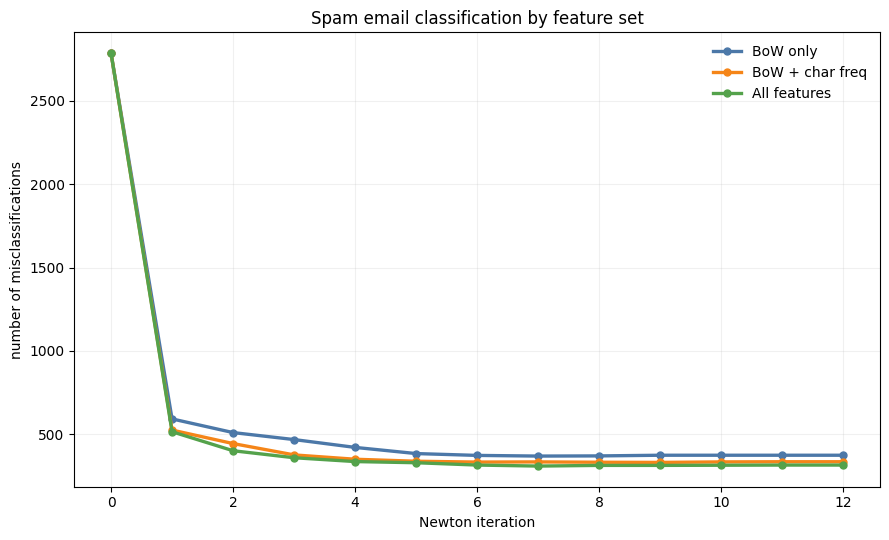

In [2]:
# QUESTION HANDLED: Exercise 9.1 - Spam email.
# ---------------------------------------------------------------------
# Repeat Example 9.2 / Figure 9.5 using the local spambase dataset and the two-
# class Softmax cost.  The chapter compares three cumulative feature sets, so we
# run the exact same Newton optimizer on each one and only change the features.
# ---------------------------------------------------------------------
# Textbook equations used here: the two-class Softmax cost in Equation (6.25)
# and its Hessian-based Newton optimization discussion around Equation (6.28).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 9 EXERCISES.
# ---------------------------------------------------------------------
# This cell gathers the imports, plotting style, dataset loaders, common feature
# metadata, and reusable optimization helpers used across Exercises 9.1, 9.9,
# 9.11, and 9.12.  Running this cell first keeps the later exercise cells focused
# on the logic specific to each problem instead of repeating boilerplate.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the notebook looks the same even if
# the active Jupyter theme or matplotlib defaults differ across environments.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Centralize the common local paths used by the Chapter 9 exercises.
WORKSPACE_PATH = Path.cwd()
HW3_PATH = WORKSPACE_PATH / "HW3"

# ---------------------------------------------------------------------
# Dataset loaders.
# Each loader returns features in the book's preferred N x P layout, meaning one
# feature per row and one data point per column whenever possible.
# ---------------------------------------------------------------------

def load_spambase_data():
    data_path = HW3_PATH / "spambase_data.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_credit_data():
    data_path = HW3_PATH / "credit_dataset.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_local_boston_housing():
    local_path = Path.home() / ".keras" / "datasets" / "boston_housing.npz"
    if local_path.exists():
        data = np.load(local_path)
        return data["x"], data["y"]

    # Fallback: if the cache is missing, ask Keras for the same dataset.
    from keras.src.datasets import boston_housing
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    return X, y


# Human-readable feature names and descriptions used by the housing exercises.
BOSTON_FEATURE_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
]
BOSTON_FEATURE_DESCRIPTIONS = {
    "CRIM": "per-capita crime rate",
    "ZN": "residential land zoned for large lots",
    "INDUS": "non-retail business acreage proportion",
    "CHAS": "Charles River indicator",
    "NOX": "nitric oxides concentration",
    "RM": "average rooms per dwelling",
    "AGE": "proportion of owner-occupied units built before 1940",
    "DIS": "distance to employment centers",
    "RAD": "accessibility to radial highways",
    "TAX": "property-tax rate",
    "PTRATIO": "pupil-teacher ratio",
    "B": "legacy race-based feature retained only to match the book",
    "LSTAT": "percentage of lower-status population",
}
CREDIT_FEATURE_DESCRIPTIONS = {
    1: "current account balance with bank",
    2: "duration (months) of previous credit",
    3: "payment status of prior credit",
    6: "current savings / stocks value",
}

# ---------------------------------------------------------------------
# Basic preprocessing helpers.
# Standard normalization is important in Chapter 9 because both boosting and l1
# regularization compare feature importance through weight values.
# ---------------------------------------------------------------------

def standard_normalize_features(X):
    means = np.mean(X, axis=1, keepdims=True)
    stds = np.std(X, axis=1, keepdims=True)
    stds[stds < 1e-12] = 1.0
    return (X - means) / stds, means, stds


def add_bias_row(X):
    # Prepend a row of ones so the first model weight acts as the intercept.
    return np.vstack([np.ones((1, X.shape[1])), X])


# ---------------------------------------------------------------------
# Linear / logistic-model helpers used repeatedly in this exercise.
# These utilities let the exercise cells talk directly in terms of scores,
# misclassifications, and costs without re-deriving the same formulas each time.
# ---------------------------------------------------------------------

def affine_scores(weights, X):
    return weights @ add_bias_row(X)


def sign_predictions_from_scores(scores):
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return predictions


def misclassifications_from_scores(scores, y):
    predictions = sign_predictions_from_scores(scores)
    return int(np.sum(predictions != y))


def binary_softmax_cost_from_scores(scores, y):
    # For labels in {-1, +1}, the two-class Softmax / logistic loss is
    # log(1 + exp(-y_p * a_p)) where a_p is the current affine score.
    return np.mean(np.logaddexp(0.0, -y * scores))


def binary_softmax_cost(weights, X, y, ridge=1e-6):
    scores = affine_scores(weights, X)
    return binary_softmax_cost_from_scores(scores, y) + 0.5 * ridge * np.sum(weights[1:] ** 2)


def binary_softmax_misclassifications(weights, X, y):
    return misclassifications_from_scores(affine_scores(weights, X), y)


def binary_softmax_gradient_hessian(weights, X, y, ridge=1e-6):
    X_aug = add_bias_row(X)
    margins = y * (weights @ X_aug)

    # sigmoid(-margin) is the uncertainty factor that appears in both the
    # gradient and Hessian of the logistic loss.
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    gradient = -(X_aug @ (y * probs).T) / X.shape[1]
    gradient[1:] += ridge * weights[1:]

    curvature_weights = probs * (1.0 - probs)
    hessian = (X_aug * curvature_weights) @ X_aug.T / X.shape[1]
    hessian[1:, 1:] += ridge * np.eye(X.shape[0])
    return gradient, hessian


def damped_newton_binary_softmax(X, y, max_its=12, ridge=1e-6):
    weights = np.zeros(X.shape[0] + 1)
    weight_history = [weights.copy()]
    cost_history = [binary_softmax_cost(weights, X, y, ridge)]
    mis_history = [binary_softmax_misclassifications(weights, X, y)]

    for _ in range(max_its):
        gradient, hessian = binary_softmax_gradient_hessian(weights, X, y, ridge)
        newton_direction = np.linalg.solve(hessian, gradient)

        step_size = 1.0
        current_cost = cost_history[-1]
        directional_derivative = gradient @ newton_direction

        # A short Armijo backtracking loop keeps Newton's method stable without
        # sacrificing the fast convergence that makes it attractive here.
        while step_size > 1e-6:
            candidate_weights = weights - step_size * newton_direction
            candidate_cost = binary_softmax_cost(candidate_weights, X, y, ridge)
            if candidate_cost <= current_cost - 1e-4 * step_size * directional_derivative:
                weights = candidate_weights
                current_cost = candidate_cost
                break
            step_size *= 0.5

        weight_history.append(weights.copy())
        cost_history.append(current_cost)
        mis_history.append(binary_softmax_misclassifications(weights, X, y))

    return np.array(weight_history), np.array(cost_history), np.array(mis_history)


# ---------------------------------------------------------------------
# Least Squares helpers for the housing-price exercises.
# ---------------------------------------------------------------------

def fit_subset_least_squares(X, y, active_features):
    X_active = np.vstack([np.ones((1, X.shape[1])), X[active_features, :]])
    weights = np.linalg.lstsq(X_active.T, y, rcond=None)[0]
    predictions = weights @ X_active
    residuals = predictions - y
    mse = np.mean(residuals ** 2)
    rmse_dollars = 1000.0 * np.sqrt(mse)
    mad_dollars = 1000.0 * np.mean(np.abs(residuals))
    return weights, predictions, mse, rmse_dollars, mad_dollars


def boosting_feature_selection(X, y, feature_names):
    remaining = list(range(X.shape[0]))
    active = []
    history = []

    for _ in range(X.shape[0]):
        best_candidate = None
        for candidate in remaining:
            candidate_active = active + [candidate]
            weights, predictions, mse, rmse_dollars, mad_dollars = fit_subset_least_squares(X, y, candidate_active)
            if best_candidate is None or mse < best_candidate["mse"]:
                best_candidate = {
                    "feature_index": candidate,
                    "feature_name": feature_names[candidate],
                    "active_features": candidate_active,
                    "weights": weights,
                    "predictions": predictions,
                    "mse": mse,
                    "rmse_dollars": rmse_dollars,
                    "mad_dollars": mad_dollars,
                }

        active = best_candidate["active_features"]
        remaining.remove(best_candidate["feature_index"])
        history.append(best_candidate)

    return history


# ---------------------------------------------------------------------
# Coordinate-wise Softmax boosting helpers for the credit-risk exercise.
# ---------------------------------------------------------------------

def optimize_single_coordinate_binary_softmax(feature_row, running_scores, y, max_its=30):
    weight = 0.0
    current_scores = running_scores + weight * feature_row
    current_cost = binary_softmax_cost_from_scores(current_scores, y)

    for _ in range(max_its):
        margins = y * (running_scores + weight * feature_row)
        probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
        gradient = -np.mean(y * feature_row * probs)
        hessian = np.mean((feature_row ** 2) * probs * (1.0 - probs))
        if hessian < 1e-12:
            break

        newton_direction = gradient / hessian
        step_size = 1.0

        while step_size > 1e-8:
            candidate_weight = weight - step_size * newton_direction
            candidate_scores = running_scores + candidate_weight * feature_row
            candidate_cost = binary_softmax_cost_from_scores(candidate_scores, y)
            if candidate_cost <= current_cost - 1e-4 * step_size * gradient * newton_direction:
                weight = candidate_weight
                current_cost = candidate_cost
                break
            step_size *= 0.5
        else:
            break

        if abs(step_size * newton_direction) < 1e-8:
            break

    return weight, current_cost


def boosting_softmax_coordinate_descent(X_aug, y, num_rounds=11):
    remaining = list(range(X_aug.shape[0]))
    running_scores = np.zeros(X_aug.shape[1])
    selected_indices = []
    selected_weights = []
    cost_history = []
    mis_history = []

    for _ in range(min(num_rounds, X_aug.shape[0])):
        best_candidate = None
        for feature_index in remaining:
            candidate_weight, candidate_cost = optimize_single_coordinate_binary_softmax(
                X_aug[feature_index, :], running_scores, y
            )
            if best_candidate is None or candidate_cost < best_candidate["cost"]:
                best_candidate = {
                    "index": feature_index,
                    "weight": candidate_weight,
                    "cost": candidate_cost,
                }

        selected_indices.append(best_candidate["index"])
        selected_weights.append(best_candidate["weight"])
        running_scores = running_scores + best_candidate["weight"] * X_aug[best_candidate["index"], :]
        remaining.remove(best_candidate["index"])
        cost_history.append(best_candidate["cost"])
        mis_history.append(misclassifications_from_scores(running_scores, y))

    final_weights = np.zeros(X_aug.shape[0])
    for index, weight in zip(selected_indices, selected_weights):
        final_weights[index] = weight

    return {
        "selected_indices": selected_indices,
        "selected_weights": np.array(selected_weights),
        "final_weights": final_weights,
        "cost_history": np.array(cost_history),
        "mis_history": np.array(mis_history),
        "running_scores": running_scores,
    }


# ---------------------------------------------------------------------
# l1-regularization helpers for Exercise 9.12.
# ---------------------------------------------------------------------

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def l1_regularized_least_squares_cost(weights, X_aug, y, lam):
    residuals = weights @ X_aug - y
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(weights[1:]))


def regularization_path_least_squares(X_aug, y, lam_values, step_size=2e-5, num_steps=1500):
    weights = np.zeros(X_aug.shape[0])
    weight_history = []
    cost_history = []

    for lam in lam_values:
        for _ in range(num_steps):
            residuals = weights @ X_aug - y
            bias_gradient = np.sum(residuals)
            next_bias = weights[0] - step_size * bias_gradient

            feature_gradient = X_aug[1:, :] @ residuals.T
            tentative_features = weights[1:] - step_size * feature_gradient
            next_features = soft_threshold(tentative_features, step_size * lam)

            weights = np.concatenate([[next_bias], next_features])

        weight_history.append(weights.copy())
        cost_history.append(l1_regularized_least_squares_cost(weights, X_aug, y, lam))

    return np.array(weight_history), np.array(cost_history)

X_spam, y_spam = load_spambase_data()

# Each later feature block contains the earlier one plus additional engineered
# statistics, so the curves isolate the value of adding new feature types.
spam_feature_sets = {
    "BoW only": X_spam[:48, :],
    "BoW + char freq": X_spam[:54, :],
    "All features": X_spam,
}
spam_feature_colors = {
    "BoW only": "#4C78A8",
    "BoW + char freq": "#F58518",
    "All features": "#54A24B",
}

spam_results = {}
for name, X_subset in spam_feature_sets.items():
    weight_history, cost_history, mis_history = damped_newton_binary_softmax(X_subset, y_spam)
    spam_results[name] = {
        "weights": weight_history,
        "costs": cost_history,
        "mis": mis_history,
        "best_mis": int(np.min(mis_history)),
        "final_mis": int(mis_history[-1]),
    }

print(f"Loaded spambase matrix shape: {(X_spam.shape[0] + 1, X_spam.shape[1])}")
for name in spam_feature_sets:
    result = spam_results[name]
    print(
        f"{name:18s} | best misclassifications = {result['best_mis']:4d} | "
        f"final misclassifications = {result['final_mis']:4d}"
    )

# Plot misclassifications versus Newton iteration to mirror the chapter's
# comparison of feature sets.
fig, ax = plt.subplots(figsize=(9, 5.5))
iterations = np.arange(len(next(iter(spam_results.values()))["mis"]))
for name in spam_feature_sets:
    ax.plot(
        iterations,
        spam_results[name]["mis"],
        color=spam_feature_colors[name],
        linewidth=2.4,
        marker="o",
        markersize=5,
        label=name,
    )

ax.set_title("Spam email classification by feature set")
ax.set_xlabel("Newton iteration")
ax.set_ylabel("number of misclassifications")
ax.grid(alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


Loaded Boston Housing matrix shape: (506, 13)
Boosting selection order: ['LSTAT', 'RM', 'PTRATIO', 'DIS', 'NOX', 'CHAS', 'B', 'ZN', 'CRIM', 'RAD', 'TAX', 'INDUS', 'AGE']
Intercept-only RMSE / MAD: $9,188 / $6,647
Best 1-feature RMSE / MAD: $6,203 / $4,505
Best 2-feature RMSE / MAD: $5,524 / $3,953
Best 4-feature RMSE / MAD: $5,113 / $3,584
Final 13-feature RMSE / MAD: $4,679 / $3,271

First five selected predictors and their interpretation:
1. LSTAT    | percentage of lower-status population | negative association in final model | round-1 RMSE $6,203
2. RM       | average rooms per dwelling | positive association in final model | round-2 RMSE $5,524
3. PTRATIO  | pupil-teacher ratio | negative association in final model | round-3 RMSE $5,209
4. DIS      | distance to employment centers | negative association in final model | round-4 RMSE $5,113
5. NOX      | nitric oxides concentration | negative association in final model | round-5 RMSE $4,964


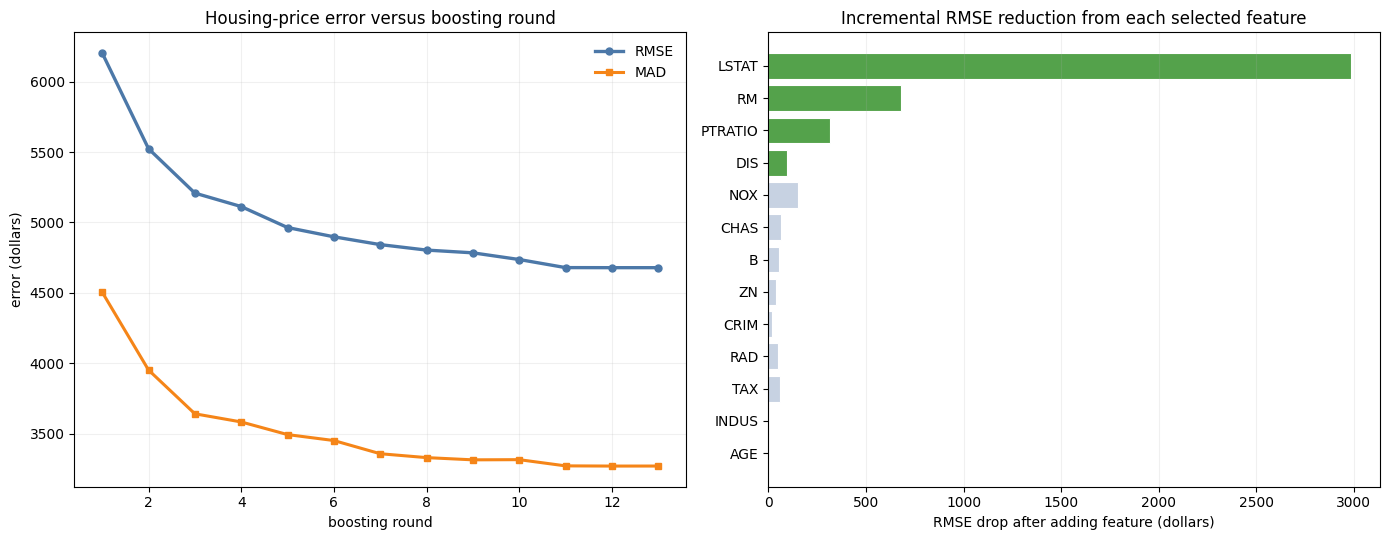

In [3]:
# QUESTION HANDLED: Exercise 9.9 - Exploring predictors of housing prices.
# ---------------------------------------------------------------------
# Repeat Example 9.6 by greedily building a Least Squares regressor one feature
# at a time.  At each round, test every still-unused feature, keep the candidate
# that gives the smallest training error, and record how the prediction error
# changes as the model grows.
# ---------------------------------------------------------------------
# Textbook equations used here: the boosting update ideas in Equations (9.14)
# and (9.15), applied to the Least Squares objective.

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 9 EXERCISES.
# ---------------------------------------------------------------------
# This cell gathers the imports, plotting style, dataset loaders, common feature
# metadata, and reusable optimization helpers used across Exercises 9.1, 9.9,
# 9.11, and 9.12.  Running this cell first keeps the later exercise cells focused
# on the logic specific to each problem instead of repeating boilerplate.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the notebook looks the same even if
# the active Jupyter theme or matplotlib defaults differ across environments.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Centralize the common local paths used by the Chapter 9 exercises.
WORKSPACE_PATH = Path.cwd()
HW3_PATH = WORKSPACE_PATH / "HW3"

# ---------------------------------------------------------------------
# Dataset loaders.
# Each loader returns features in the book's preferred N x P layout, meaning one
# feature per row and one data point per column whenever possible.
# ---------------------------------------------------------------------

def load_spambase_data():
    data_path = HW3_PATH / "spambase_data.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_credit_data():
    data_path = HW3_PATH / "credit_dataset.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_local_boston_housing():
    local_path = Path.home() / ".keras" / "datasets" / "boston_housing.npz"
    if local_path.exists():
        data = np.load(local_path)
        return data["x"], data["y"]

    # Fallback: if the cache is missing, ask Keras for the same dataset.
    from keras.src.datasets import boston_housing
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    return X, y


# Human-readable feature names and descriptions used by the housing exercises.
BOSTON_FEATURE_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
]
BOSTON_FEATURE_DESCRIPTIONS = {
    "CRIM": "per-capita crime rate",
    "ZN": "residential land zoned for large lots",
    "INDUS": "non-retail business acreage proportion",
    "CHAS": "Charles River indicator",
    "NOX": "nitric oxides concentration",
    "RM": "average rooms per dwelling",
    "AGE": "proportion of owner-occupied units built before 1940",
    "DIS": "distance to employment centers",
    "RAD": "accessibility to radial highways",
    "TAX": "property-tax rate",
    "PTRATIO": "pupil-teacher ratio",
    "B": "legacy race-based feature retained only to match the book",
    "LSTAT": "percentage of lower-status population",
}
CREDIT_FEATURE_DESCRIPTIONS = {
    1: "current account balance with bank",
    2: "duration (months) of previous credit",
    3: "payment status of prior credit",
    6: "current savings / stocks value",
}

# ---------------------------------------------------------------------
# Basic preprocessing helpers.
# Standard normalization is important in Chapter 9 because both boosting and l1
# regularization compare feature importance through weight values.
# ---------------------------------------------------------------------

def standard_normalize_features(X):
    means = np.mean(X, axis=1, keepdims=True)
    stds = np.std(X, axis=1, keepdims=True)
    stds[stds < 1e-12] = 1.0
    return (X - means) / stds, means, stds


def add_bias_row(X):
    # Prepend a row of ones so the first model weight acts as the intercept.
    return np.vstack([np.ones((1, X.shape[1])), X])


# ---------------------------------------------------------------------
# Linear / logistic-model helpers used repeatedly in this exercise.
# These utilities let the exercise cells talk directly in terms of scores,
# misclassifications, and costs without re-deriving the same formulas each time.
# ---------------------------------------------------------------------

def affine_scores(weights, X):
    return weights @ add_bias_row(X)


def sign_predictions_from_scores(scores):
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return predictions


def misclassifications_from_scores(scores, y):
    predictions = sign_predictions_from_scores(scores)
    return int(np.sum(predictions != y))


def binary_softmax_cost_from_scores(scores, y):
    # For labels in {-1, +1}, the two-class Softmax / logistic loss is
    # log(1 + exp(-y_p * a_p)) where a_p is the current affine score.
    return np.mean(np.logaddexp(0.0, -y * scores))


def binary_softmax_cost(weights, X, y, ridge=1e-6):
    scores = affine_scores(weights, X)
    return binary_softmax_cost_from_scores(scores, y) + 0.5 * ridge * np.sum(weights[1:] ** 2)


def binary_softmax_misclassifications(weights, X, y):
    return misclassifications_from_scores(affine_scores(weights, X), y)


def binary_softmax_gradient_hessian(weights, X, y, ridge=1e-6):
    X_aug = add_bias_row(X)
    margins = y * (weights @ X_aug)

    # sigmoid(-margin) is the uncertainty factor that appears in both the
    # gradient and Hessian of the logistic loss.
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    gradient = -(X_aug @ (y * probs).T) / X.shape[1]
    gradient[1:] += ridge * weights[1:]

    curvature_weights = probs * (1.0 - probs)
    hessian = (X_aug * curvature_weights) @ X_aug.T / X.shape[1]
    hessian[1:, 1:] += ridge * np.eye(X.shape[0])
    return gradient, hessian


def damped_newton_binary_softmax(X, y, max_its=12, ridge=1e-6):
    weights = np.zeros(X.shape[0] + 1)
    weight_history = [weights.copy()]
    cost_history = [binary_softmax_cost(weights, X, y, ridge)]
    mis_history = [binary_softmax_misclassifications(weights, X, y)]

    for _ in range(max_its):
        gradient, hessian = binary_softmax_gradient_hessian(weights, X, y, ridge)
        newton_direction = np.linalg.solve(hessian, gradient)

        step_size = 1.0
        current_cost = cost_history[-1]
        directional_derivative = gradient @ newton_direction

        # A short Armijo backtracking loop keeps Newton's method stable without
        # sacrificing the fast convergence that makes it attractive here.
        while step_size > 1e-6:
            candidate_weights = weights - step_size * newton_direction
            candidate_cost = binary_softmax_cost(candidate_weights, X, y, ridge)
            if candidate_cost <= current_cost - 1e-4 * step_size * directional_derivative:
                weights = candidate_weights
                current_cost = candidate_cost
                break
            step_size *= 0.5

        weight_history.append(weights.copy())
        cost_history.append(current_cost)
        mis_history.append(binary_softmax_misclassifications(weights, X, y))

    return np.array(weight_history), np.array(cost_history), np.array(mis_history)


# ---------------------------------------------------------------------
# Least Squares helpers for the housing-price exercises.
# ---------------------------------------------------------------------

def fit_subset_least_squares(X, y, active_features):
    X_active = np.vstack([np.ones((1, X.shape[1])), X[active_features, :]])
    weights = np.linalg.lstsq(X_active.T, y, rcond=None)[0]
    predictions = weights @ X_active
    residuals = predictions - y
    mse = np.mean(residuals ** 2)
    rmse_dollars = 1000.0 * np.sqrt(mse)
    mad_dollars = 1000.0 * np.mean(np.abs(residuals))
    return weights, predictions, mse, rmse_dollars, mad_dollars


def boosting_feature_selection(X, y, feature_names):
    remaining = list(range(X.shape[0]))
    active = []
    history = []

    for _ in range(X.shape[0]):
        best_candidate = None
        for candidate in remaining:
            candidate_active = active + [candidate]
            weights, predictions, mse, rmse_dollars, mad_dollars = fit_subset_least_squares(X, y, candidate_active)
            if best_candidate is None or mse < best_candidate["mse"]:
                best_candidate = {
                    "feature_index": candidate,
                    "feature_name": feature_names[candidate],
                    "active_features": candidate_active,
                    "weights": weights,
                    "predictions": predictions,
                    "mse": mse,
                    "rmse_dollars": rmse_dollars,
                    "mad_dollars": mad_dollars,
                }

        active = best_candidate["active_features"]
        remaining.remove(best_candidate["feature_index"])
        history.append(best_candidate)

    return history


# ---------------------------------------------------------------------
# Coordinate-wise Softmax boosting helpers for the credit-risk exercise.
# ---------------------------------------------------------------------

def optimize_single_coordinate_binary_softmax(feature_row, running_scores, y, max_its=30):
    weight = 0.0
    current_scores = running_scores + weight * feature_row
    current_cost = binary_softmax_cost_from_scores(current_scores, y)

    for _ in range(max_its):
        margins = y * (running_scores + weight * feature_row)
        probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
        gradient = -np.mean(y * feature_row * probs)
        hessian = np.mean((feature_row ** 2) * probs * (1.0 - probs))
        if hessian < 1e-12:
            break

        newton_direction = gradient / hessian
        step_size = 1.0

        while step_size > 1e-8:
            candidate_weight = weight - step_size * newton_direction
            candidate_scores = running_scores + candidate_weight * feature_row
            candidate_cost = binary_softmax_cost_from_scores(candidate_scores, y)
            if candidate_cost <= current_cost - 1e-4 * step_size * gradient * newton_direction:
                weight = candidate_weight
                current_cost = candidate_cost
                break
            step_size *= 0.5
        else:
            break

        if abs(step_size * newton_direction) < 1e-8:
            break

    return weight, current_cost


def boosting_softmax_coordinate_descent(X_aug, y, num_rounds=11):
    remaining = list(range(X_aug.shape[0]))
    running_scores = np.zeros(X_aug.shape[1])
    selected_indices = []
    selected_weights = []
    cost_history = []
    mis_history = []

    for _ in range(min(num_rounds, X_aug.shape[0])):
        best_candidate = None
        for feature_index in remaining:
            candidate_weight, candidate_cost = optimize_single_coordinate_binary_softmax(
                X_aug[feature_index, :], running_scores, y
            )
            if best_candidate is None or candidate_cost < best_candidate["cost"]:
                best_candidate = {
                    "index": feature_index,
                    "weight": candidate_weight,
                    "cost": candidate_cost,
                }

        selected_indices.append(best_candidate["index"])
        selected_weights.append(best_candidate["weight"])
        running_scores = running_scores + best_candidate["weight"] * X_aug[best_candidate["index"], :]
        remaining.remove(best_candidate["index"])
        cost_history.append(best_candidate["cost"])
        mis_history.append(misclassifications_from_scores(running_scores, y))

    final_weights = np.zeros(X_aug.shape[0])
    for index, weight in zip(selected_indices, selected_weights):
        final_weights[index] = weight

    return {
        "selected_indices": selected_indices,
        "selected_weights": np.array(selected_weights),
        "final_weights": final_weights,
        "cost_history": np.array(cost_history),
        "mis_history": np.array(mis_history),
        "running_scores": running_scores,
    }


# ---------------------------------------------------------------------
# l1-regularization helpers for Exercise 9.12.
# ---------------------------------------------------------------------

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def l1_regularized_least_squares_cost(weights, X_aug, y, lam):
    residuals = weights @ X_aug - y
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(weights[1:]))


def regularization_path_least_squares(X_aug, y, lam_values, step_size=2e-5, num_steps=1500):
    weights = np.zeros(X_aug.shape[0])
    weight_history = []
    cost_history = []

    for lam in lam_values:
        for _ in range(num_steps):
            residuals = weights @ X_aug - y
            bias_gradient = np.sum(residuals)
            next_bias = weights[0] - step_size * bias_gradient

            feature_gradient = X_aug[1:, :] @ residuals.T
            tentative_features = weights[1:] - step_size * feature_gradient
            next_features = soft_threshold(tentative_features, step_size * lam)

            weights = np.concatenate([[next_bias], next_features])

        weight_history.append(weights.copy())
        cost_history.append(l1_regularized_least_squares_cost(weights, X_aug, y, lam))

    return np.array(weight_history), np.array(cost_history)

X_housing_rows, y_housing = load_local_boston_housing()
X_housing_raw = X_housing_rows.T
X_housing, X_housing_means, X_housing_stds = standard_normalize_features(X_housing_raw)

boosting_history_housing = boosting_feature_selection(X_housing, y_housing, BOSTON_FEATURE_NAMES)
_, _, _, baseline_rmse_dollars, baseline_mad_dollars = fit_subset_least_squares(X_housing, y_housing, [])

# Summarize the boosting path so we can discuss both feature order and the size
# of the error reduction provided by each new predictor.
selection_order_housing = [step["feature_name"] for step in boosting_history_housing]
rmse_history_housing = np.array([step["rmse_dollars"] for step in boosting_history_housing])
mad_history_housing = np.array([step["mad_dollars"] for step in boosting_history_housing])
rmse_drops_housing = np.r_[
    baseline_rmse_dollars - rmse_history_housing[0],
    rmse_history_housing[:-1] - rmse_history_housing[1:],
]
final_step_housing = boosting_history_housing[-1]
final_coefficient_map_housing = {
    BOSTON_FEATURE_NAMES[index]: coefficient
    for index, coefficient in zip(final_step_housing["active_features"], final_step_housing["weights"][1:])
}

print(f"Loaded Boston Housing matrix shape: {X_housing_rows.shape}")
print(f"Boosting selection order: {selection_order_housing}")
print(f"Intercept-only RMSE / MAD: ${baseline_rmse_dollars:,.0f} / ${baseline_mad_dollars:,.0f}")
print(f"Best 1-feature RMSE / MAD: ${rmse_history_housing[0]:,.0f} / ${mad_history_housing[0]:,.0f}")
print(f"Best 2-feature RMSE / MAD: ${rmse_history_housing[1]:,.0f} / ${mad_history_housing[1]:,.0f}")
print(f"Best 4-feature RMSE / MAD: ${rmse_history_housing[3]:,.0f} / ${mad_history_housing[3]:,.0f}")
print(f"Final 13-feature RMSE / MAD: ${rmse_history_housing[-1]:,.0f} / ${mad_history_housing[-1]:,.0f}")
print()
print("First five selected predictors and their interpretation:")
for rank, step in enumerate(boosting_history_housing[:5], start=1):
    coefficient = final_coefficient_map_housing[step["feature_name"]]
    direction = "positive" if coefficient > 0 else "negative"
    print(
        f"{rank}. {step['feature_name']:8s} | {BOSTON_FEATURE_DESCRIPTIONS[step['feature_name']]} | "
        f"{direction} association in final model | round-{rank} RMSE ${step['rmse_dollars']:,.0f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
rounds_housing = np.arange(1, len(boosting_history_housing) + 1)

# The left panel shows the global trend: a small number of early features capture
# most of the predictive value before later additions give diminishing returns.
axes[0].plot(rounds_housing, rmse_history_housing, color="#4C78A8", linewidth=2.4, marker="o", markersize=5, label="RMSE")
axes[0].plot(rounds_housing, mad_history_housing, color="#F58518", linewidth=2.2, marker="s", markersize=4, label="MAD")
axes[0].set_title("Housing-price error versus boosting round")
axes[0].set_xlabel("boosting round")
axes[0].set_ylabel("error (dollars)")
axes[0].grid(alpha=0.18)
axes[0].legend(frameon=False)

# The right panel isolates the realized improvement provided by each feature at
# the exact moment it entered the model.
bar_colors_housing = ["#54A24B" if i < 4 else "#C7D2E2" for i in range(len(selection_order_housing))]
axes[1].barh(selection_order_housing, rmse_drops_housing, color=bar_colors_housing, edgecolor="white", linewidth=0.8)
axes[1].invert_yaxis()
axes[1].set_title("Incremental RMSE reduction from each selected feature")
axes[1].set_xlabel("RMSE drop after adding feature (dollars)")
axes[1].grid(alpha=0.18, axis="x")

plt.tight_layout()
plt.show()


Loaded credit matrix shape: (21, 1000)
Boosting selected weight indices: [0, 1, 2, 3, 6, 10, 8, 9, 7, 14, 20]
Final training misclassifications after 11 rounds: 234

Top four non-bias predictors recovered by boosting:
1. feature  1 | current account balance with bank | positive association with good credit risk | weight 0.797
2. feature  2 | duration (months) of previous credit | negative association with good credit risk | weight -0.433
3. feature  3 | payment status of prior credit | positive association with good credit risk | weight 0.374
4. feature  6 | current savings / stocks value | positive association with good credit risk | weight 0.294


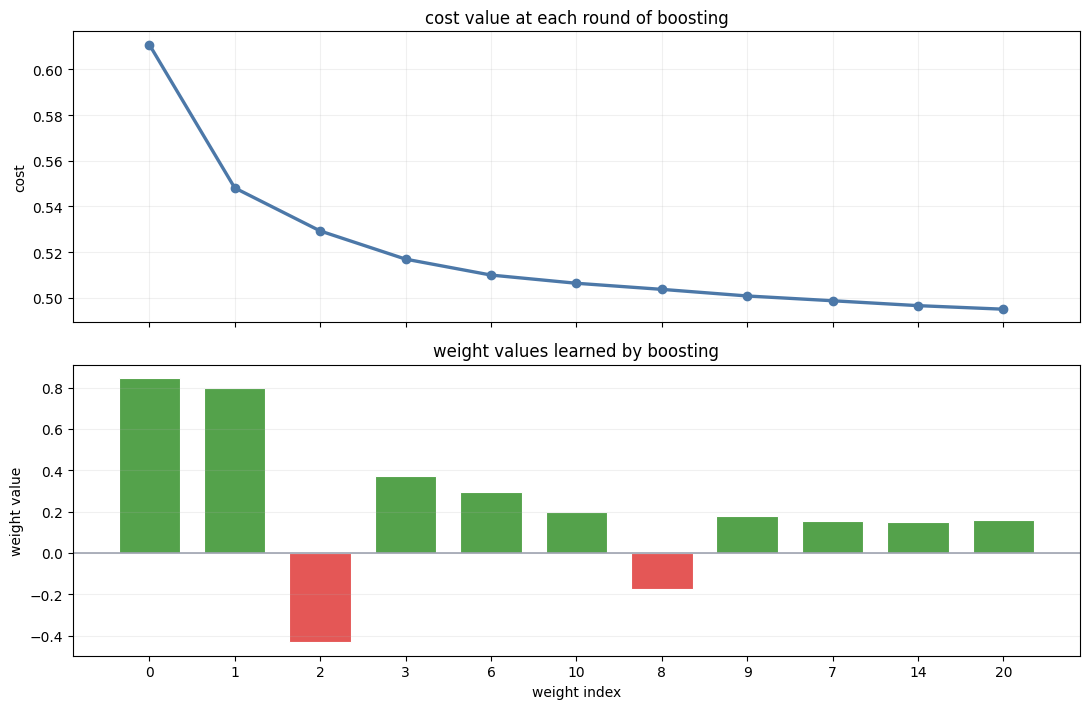

In [4]:
# QUESTION HANDLED: Exercise 9.11 - Studying important predictors of credit risk.
# ---------------------------------------------------------------------
# Repeat Example 9.7 using the local German credit dataset and the Section 9.6.1
# boosting procedure for linear classification.  This is true boosting: one new
# coordinate is tuned at a time while all previously selected coordinates remain
# frozen, so the selection order is itself the main feature-importance signal.
# ---------------------------------------------------------------------
# Textbook equations used here: the boosting update ideas in Equations (9.14)
# and (9.15), combined with the two-class Softmax cost in Equation (6.25).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 9 EXERCISES.
# ---------------------------------------------------------------------
# This cell gathers the imports, plotting style, dataset loaders, common feature
# metadata, and reusable optimization helpers used across Exercises 9.1, 9.9,
# 9.11, and 9.12.  Running this cell first keeps the later exercise cells focused
# on the logic specific to each problem instead of repeating boilerplate.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the notebook looks the same even if
# the active Jupyter theme or matplotlib defaults differ across environments.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Centralize the common local paths used by the Chapter 9 exercises.
WORKSPACE_PATH = Path.cwd()
HW3_PATH = WORKSPACE_PATH / "HW3"

# ---------------------------------------------------------------------
# Dataset loaders.
# Each loader returns features in the book's preferred N x P layout, meaning one
# feature per row and one data point per column whenever possible.
# ---------------------------------------------------------------------

def load_spambase_data():
    data_path = HW3_PATH / "spambase_data.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_credit_data():
    data_path = HW3_PATH / "credit_dataset.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_local_boston_housing():
    local_path = Path.home() / ".keras" / "datasets" / "boston_housing.npz"
    if local_path.exists():
        data = np.load(local_path)
        return data["x"], data["y"]

    # Fallback: if the cache is missing, ask Keras for the same dataset.
    from keras.src.datasets import boston_housing
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    return X, y


# Human-readable feature names and descriptions used by the housing exercises.
BOSTON_FEATURE_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
]
BOSTON_FEATURE_DESCRIPTIONS = {
    "CRIM": "per-capita crime rate",
    "ZN": "residential land zoned for large lots",
    "INDUS": "non-retail business acreage proportion",
    "CHAS": "Charles River indicator",
    "NOX": "nitric oxides concentration",
    "RM": "average rooms per dwelling",
    "AGE": "proportion of owner-occupied units built before 1940",
    "DIS": "distance to employment centers",
    "RAD": "accessibility to radial highways",
    "TAX": "property-tax rate",
    "PTRATIO": "pupil-teacher ratio",
    "B": "legacy race-based feature retained only to match the book",
    "LSTAT": "percentage of lower-status population",
}
CREDIT_FEATURE_DESCRIPTIONS = {
    1: "current account balance with bank",
    2: "duration (months) of previous credit",
    3: "payment status of prior credit",
    6: "current savings / stocks value",
}

# ---------------------------------------------------------------------
# Basic preprocessing helpers.
# Standard normalization is important in Chapter 9 because both boosting and l1
# regularization compare feature importance through weight values.
# ---------------------------------------------------------------------

def standard_normalize_features(X):
    means = np.mean(X, axis=1, keepdims=True)
    stds = np.std(X, axis=1, keepdims=True)
    stds[stds < 1e-12] = 1.0
    return (X - means) / stds, means, stds


def add_bias_row(X):
    # Prepend a row of ones so the first model weight acts as the intercept.
    return np.vstack([np.ones((1, X.shape[1])), X])


# ---------------------------------------------------------------------
# Linear / logistic-model helpers used repeatedly in this exercise.
# These utilities let the exercise cells talk directly in terms of scores,
# misclassifications, and costs without re-deriving the same formulas each time.
# ---------------------------------------------------------------------

def affine_scores(weights, X):
    return weights @ add_bias_row(X)


def sign_predictions_from_scores(scores):
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return predictions


def misclassifications_from_scores(scores, y):
    predictions = sign_predictions_from_scores(scores)
    return int(np.sum(predictions != y))


def binary_softmax_cost_from_scores(scores, y):
    # For labels in {-1, +1}, the two-class Softmax / logistic loss is
    # log(1 + exp(-y_p * a_p)) where a_p is the current affine score.
    return np.mean(np.logaddexp(0.0, -y * scores))


def binary_softmax_cost(weights, X, y, ridge=1e-6):
    scores = affine_scores(weights, X)
    return binary_softmax_cost_from_scores(scores, y) + 0.5 * ridge * np.sum(weights[1:] ** 2)


def binary_softmax_misclassifications(weights, X, y):
    return misclassifications_from_scores(affine_scores(weights, X), y)


def binary_softmax_gradient_hessian(weights, X, y, ridge=1e-6):
    X_aug = add_bias_row(X)
    margins = y * (weights @ X_aug)

    # sigmoid(-margin) is the uncertainty factor that appears in both the
    # gradient and Hessian of the logistic loss.
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    gradient = -(X_aug @ (y * probs).T) / X.shape[1]
    gradient[1:] += ridge * weights[1:]

    curvature_weights = probs * (1.0 - probs)
    hessian = (X_aug * curvature_weights) @ X_aug.T / X.shape[1]
    hessian[1:, 1:] += ridge * np.eye(X.shape[0])
    return gradient, hessian


def damped_newton_binary_softmax(X, y, max_its=12, ridge=1e-6):
    weights = np.zeros(X.shape[0] + 1)
    weight_history = [weights.copy()]
    cost_history = [binary_softmax_cost(weights, X, y, ridge)]
    mis_history = [binary_softmax_misclassifications(weights, X, y)]

    for _ in range(max_its):
        gradient, hessian = binary_softmax_gradient_hessian(weights, X, y, ridge)
        newton_direction = np.linalg.solve(hessian, gradient)

        step_size = 1.0
        current_cost = cost_history[-1]
        directional_derivative = gradient @ newton_direction

        # A short Armijo backtracking loop keeps Newton's method stable without
        # sacrificing the fast convergence that makes it attractive here.
        while step_size > 1e-6:
            candidate_weights = weights - step_size * newton_direction
            candidate_cost = binary_softmax_cost(candidate_weights, X, y, ridge)
            if candidate_cost <= current_cost - 1e-4 * step_size * directional_derivative:
                weights = candidate_weights
                current_cost = candidate_cost
                break
            step_size *= 0.5

        weight_history.append(weights.copy())
        cost_history.append(current_cost)
        mis_history.append(binary_softmax_misclassifications(weights, X, y))

    return np.array(weight_history), np.array(cost_history), np.array(mis_history)


# ---------------------------------------------------------------------
# Least Squares helpers for the housing-price exercises.
# ---------------------------------------------------------------------

def fit_subset_least_squares(X, y, active_features):
    X_active = np.vstack([np.ones((1, X.shape[1])), X[active_features, :]])
    weights = np.linalg.lstsq(X_active.T, y, rcond=None)[0]
    predictions = weights @ X_active
    residuals = predictions - y
    mse = np.mean(residuals ** 2)
    rmse_dollars = 1000.0 * np.sqrt(mse)
    mad_dollars = 1000.0 * np.mean(np.abs(residuals))
    return weights, predictions, mse, rmse_dollars, mad_dollars


def boosting_feature_selection(X, y, feature_names):
    remaining = list(range(X.shape[0]))
    active = []
    history = []

    for _ in range(X.shape[0]):
        best_candidate = None
        for candidate in remaining:
            candidate_active = active + [candidate]
            weights, predictions, mse, rmse_dollars, mad_dollars = fit_subset_least_squares(X, y, candidate_active)
            if best_candidate is None or mse < best_candidate["mse"]:
                best_candidate = {
                    "feature_index": candidate,
                    "feature_name": feature_names[candidate],
                    "active_features": candidate_active,
                    "weights": weights,
                    "predictions": predictions,
                    "mse": mse,
                    "rmse_dollars": rmse_dollars,
                    "mad_dollars": mad_dollars,
                }

        active = best_candidate["active_features"]
        remaining.remove(best_candidate["feature_index"])
        history.append(best_candidate)

    return history


# ---------------------------------------------------------------------
# Coordinate-wise Softmax boosting helpers for the credit-risk exercise.
# ---------------------------------------------------------------------

def optimize_single_coordinate_binary_softmax(feature_row, running_scores, y, max_its=30):
    weight = 0.0
    current_scores = running_scores + weight * feature_row
    current_cost = binary_softmax_cost_from_scores(current_scores, y)

    for _ in range(max_its):
        margins = y * (running_scores + weight * feature_row)
        probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
        gradient = -np.mean(y * feature_row * probs)
        hessian = np.mean((feature_row ** 2) * probs * (1.0 - probs))
        if hessian < 1e-12:
            break

        newton_direction = gradient / hessian
        step_size = 1.0

        while step_size > 1e-8:
            candidate_weight = weight - step_size * newton_direction
            candidate_scores = running_scores + candidate_weight * feature_row
            candidate_cost = binary_softmax_cost_from_scores(candidate_scores, y)
            if candidate_cost <= current_cost - 1e-4 * step_size * gradient * newton_direction:
                weight = candidate_weight
                current_cost = candidate_cost
                break
            step_size *= 0.5
        else:
            break

        if abs(step_size * newton_direction) < 1e-8:
            break

    return weight, current_cost


def boosting_softmax_coordinate_descent(X_aug, y, num_rounds=11):
    remaining = list(range(X_aug.shape[0]))
    running_scores = np.zeros(X_aug.shape[1])
    selected_indices = []
    selected_weights = []
    cost_history = []
    mis_history = []

    for _ in range(min(num_rounds, X_aug.shape[0])):
        best_candidate = None
        for feature_index in remaining:
            candidate_weight, candidate_cost = optimize_single_coordinate_binary_softmax(
                X_aug[feature_index, :], running_scores, y
            )
            if best_candidate is None or candidate_cost < best_candidate["cost"]:
                best_candidate = {
                    "index": feature_index,
                    "weight": candidate_weight,
                    "cost": candidate_cost,
                }

        selected_indices.append(best_candidate["index"])
        selected_weights.append(best_candidate["weight"])
        running_scores = running_scores + best_candidate["weight"] * X_aug[best_candidate["index"], :]
        remaining.remove(best_candidate["index"])
        cost_history.append(best_candidate["cost"])
        mis_history.append(misclassifications_from_scores(running_scores, y))

    final_weights = np.zeros(X_aug.shape[0])
    for index, weight in zip(selected_indices, selected_weights):
        final_weights[index] = weight

    return {
        "selected_indices": selected_indices,
        "selected_weights": np.array(selected_weights),
        "final_weights": final_weights,
        "cost_history": np.array(cost_history),
        "mis_history": np.array(mis_history),
        "running_scores": running_scores,
    }


# ---------------------------------------------------------------------
# l1-regularization helpers for Exercise 9.12.
# ---------------------------------------------------------------------

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def l1_regularized_least_squares_cost(weights, X_aug, y, lam):
    residuals = weights @ X_aug - y
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(weights[1:]))


def regularization_path_least_squares(X_aug, y, lam_values, step_size=2e-5, num_steps=1500):
    weights = np.zeros(X_aug.shape[0])
    weight_history = []
    cost_history = []

    for lam in lam_values:
        for _ in range(num_steps):
            residuals = weights @ X_aug - y
            bias_gradient = np.sum(residuals)
            next_bias = weights[0] - step_size * bias_gradient

            feature_gradient = X_aug[1:, :] @ residuals.T
            tentative_features = weights[1:] - step_size * feature_gradient
            next_features = soft_threshold(tentative_features, step_size * lam)

            weights = np.concatenate([[next_bias], next_features])

        weight_history.append(weights.copy())
        cost_history.append(l1_regularized_least_squares_cost(weights, X_aug, y, lam))

    return np.array(weight_history), np.array(cost_history)

X_credit_raw, y_credit = load_credit_data()
X_credit, credit_means, credit_stds = standard_normalize_features(X_credit_raw)
X_credit_aug = add_bias_row(X_credit)

credit_boosting_result = boosting_softmax_coordinate_descent(X_credit_aug, y_credit, num_rounds=11)
selected_indices_credit = credit_boosting_result["selected_indices"]
selected_weights_credit = credit_boosting_result["selected_weights"]
cost_history_credit = credit_boosting_result["cost_history"]
mis_history_credit = credit_boosting_result["mis_history"]
final_weights_credit = credit_boosting_result["final_weights"]

print(f"Loaded credit matrix shape: {(X_credit_raw.shape[0] + 1, X_credit_raw.shape[1])}")
print(f"Boosting selected weight indices: {selected_indices_credit}")
print(f"Final training misclassifications after {len(selected_indices_credit)} rounds: {mis_history_credit[-1]}")
print()
print("Top four non-bias predictors recovered by boosting:")
for rank, feature_index in enumerate(selected_indices_credit[1:5], start=1):
    weight = final_weights_credit[feature_index]
    direction = "positive" if weight > 0 else "negative"
    description = CREDIT_FEATURE_DESCRIPTIONS.get(feature_index, f"feature {feature_index}")
    print(
        f"{rank}. feature {feature_index:2d} | {description} | "
        f"{direction} association with good credit risk | weight {weight:.3f}"
    )

# Match the Figure 9.20 style: x positions are boosting rounds, while the tick
# labels show the actual weight index chosen at that round.
round_positions_credit = np.arange(len(selected_indices_credit))
selected_labels_credit = [str(index) for index in selected_indices_credit]
weight_colors_credit = ["#54A24B" if weight > 0 else "#E45756" for weight in selected_weights_credit]

fig, axes = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True)

axes[0].plot(
    round_positions_credit,
    cost_history_credit,
    color="#4C78A8",
    linewidth=2.4,
    marker="o",
    markersize=6,
)
axes[0].set_title("cost value at each round of boosting")
axes[0].set_ylabel("cost")
axes[0].grid(alpha=0.18)

axes[1].bar(
    round_positions_credit,
    selected_weights_credit,
    color=weight_colors_credit,
    edgecolor="white",
    linewidth=0.8,
    width=0.72,
)
axes[1].axhline(0.0, color="#9EA3B0", linewidth=1.2)
axes[1].set_title("weight values learned by boosting")
axes[1].set_xlabel("weight index")
axes[1].set_ylabel("weight value")
axes[1].grid(alpha=0.18, axis="y")
axes[1].set_xticks(round_positions_credit)
axes[1].set_xticklabels(selected_labels_credit)

plt.tight_layout()
plt.show()


Loaded Boston Housing matrix shape: (506, 13)
Regularization path uses 50 lambda values from 0 to 130
Final regularized cost at largest lambda: 7661.726

Dominant feature-touching weights at the largest lambda value:
1. feature 13 (LSTAT  ) | percentage of lower-status population | negative weight -3.711
2. feature  6 (RM     ) | average rooms per dwelling | positive weight 2.981
3. feature 11 (PTRATIO) | pupil-teacher ratio | negative weight -1.764

Conclusion: the largest-lambda model is dominated by features 6, 13, and 11 (RM, LSTAT, and PTRATIO), and the first two agree with the earlier boosting result.


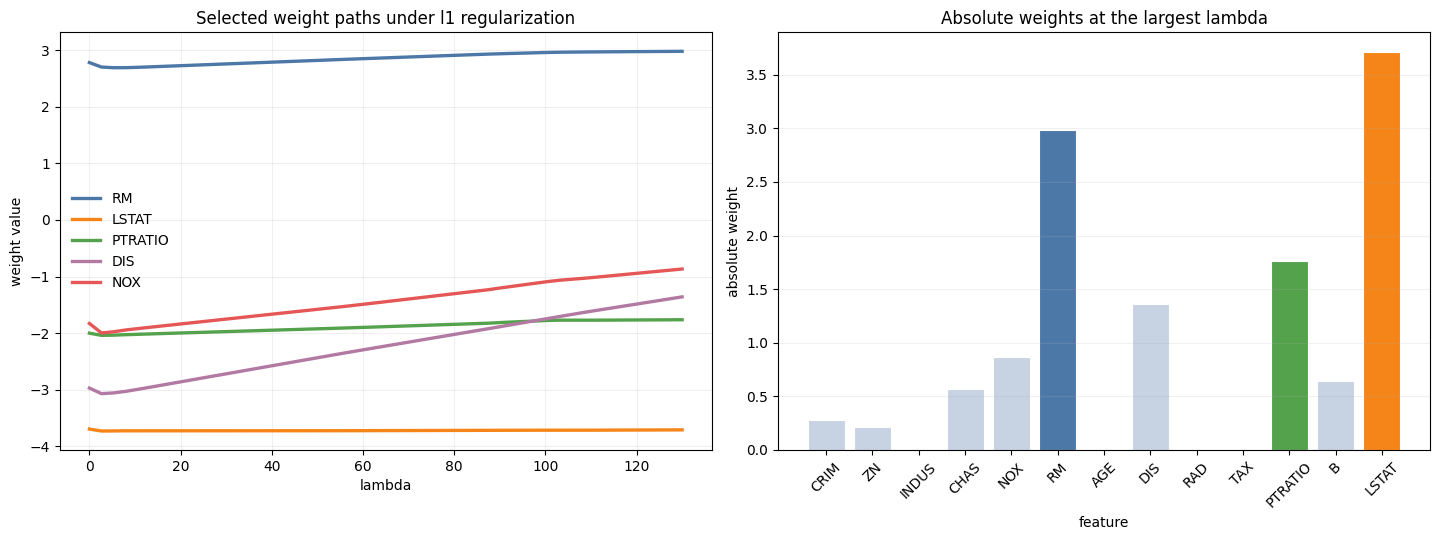

In [5]:
# QUESTION HANDLED: Exercise 9.12 - Exploring predictors of housing prices via regularization.
# ---------------------------------------------------------------------
# Repeat Example 9.11 by sweeping through 50 evenly spaced l1-regularization
# values on the Boston Housing dataset.  The lambda path gives a top-down view of
# feature importance: as regularization grows, less important weights shrink away
# and the dominant features remain visible.
# ---------------------------------------------------------------------
# Textbook equations used here: the l1-regularized Least Squares objective in
# Equation (9.23) and the penalty definition in Equation (9.25).

# ---------------------------------------------------------------------
# SELF-CONTAINED HELPER BLOCK:
# Everything below is repeated locally on purpose so this single cell can
# be run from a fresh kernel without relying on any earlier notebook cell.
# ---------------------------------------------------------------------
# HELPER IMPORTS AND FUNCTIONS FOR CHAPTER 9 EXERCISES.
# ---------------------------------------------------------------------
# This cell gathers the imports, plotting style, dataset loaders, common feature
# metadata, and reusable optimization helpers used across Exercises 9.1, 9.9,
# 9.11, and 9.12.  Running this cell first keeps the later exercise cells focused
# on the logic specific to each problem instead of repeating boilerplate.
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use a light plotting style explicitly so the notebook looks the same even if
# the active Jupyter theme or matplotlib defaults differ across environments.
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Centralize the common local paths used by the Chapter 9 exercises.
WORKSPACE_PATH = Path.cwd()
HW3_PATH = WORKSPACE_PATH / "HW3"

# ---------------------------------------------------------------------
# Dataset loaders.
# Each loader returns features in the book's preferred N x P layout, meaning one
# feature per row and one data point per column whenever possible.
# ---------------------------------------------------------------------

def load_spambase_data():
    data_path = HW3_PATH / "spambase_data.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_credit_data():
    data_path = HW3_PATH / "credit_dataset.csv"
    data = np.loadtxt(data_path, delimiter=",")
    X = data[:-1, :]
    y = data[-1, :]
    return X, y


def load_local_boston_housing():
    local_path = Path.home() / ".keras" / "datasets" / "boston_housing.npz"
    if local_path.exists():
        data = np.load(local_path)
        return data["x"], data["y"]

    # Fallback: if the cache is missing, ask Keras for the same dataset.
    from keras.src.datasets import boston_housing
    (x_train, y_train), (x_test, y_test) = boston_housing.load_data()
    X = np.vstack([x_train, x_test])
    y = np.hstack([y_train, y_test])
    return X, y


# Human-readable feature names and descriptions used by the housing exercises.
BOSTON_FEATURE_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
]
BOSTON_FEATURE_DESCRIPTIONS = {
    "CRIM": "per-capita crime rate",
    "ZN": "residential land zoned for large lots",
    "INDUS": "non-retail business acreage proportion",
    "CHAS": "Charles River indicator",
    "NOX": "nitric oxides concentration",
    "RM": "average rooms per dwelling",
    "AGE": "proportion of owner-occupied units built before 1940",
    "DIS": "distance to employment centers",
    "RAD": "accessibility to radial highways",
    "TAX": "property-tax rate",
    "PTRATIO": "pupil-teacher ratio",
    "B": "legacy race-based feature retained only to match the book",
    "LSTAT": "percentage of lower-status population",
}
CREDIT_FEATURE_DESCRIPTIONS = {
    1: "current account balance with bank",
    2: "duration (months) of previous credit",
    3: "payment status of prior credit",
    6: "current savings / stocks value",
}

# ---------------------------------------------------------------------
# Basic preprocessing helpers.
# Standard normalization is important in Chapter 9 because both boosting and l1
# regularization compare feature importance through weight values.
# ---------------------------------------------------------------------

def standard_normalize_features(X):
    means = np.mean(X, axis=1, keepdims=True)
    stds = np.std(X, axis=1, keepdims=True)
    stds[stds < 1e-12] = 1.0
    return (X - means) / stds, means, stds


def add_bias_row(X):
    # Prepend a row of ones so the first model weight acts as the intercept.
    return np.vstack([np.ones((1, X.shape[1])), X])


# ---------------------------------------------------------------------
# Linear / logistic-model helpers used repeatedly in this exercise.
# These utilities let the exercise cells talk directly in terms of scores,
# misclassifications, and costs without re-deriving the same formulas each time.
# ---------------------------------------------------------------------

def affine_scores(weights, X):
    return weights @ add_bias_row(X)


def sign_predictions_from_scores(scores):
    predictions = np.sign(scores)
    predictions[predictions == 0] = 1
    return predictions


def misclassifications_from_scores(scores, y):
    predictions = sign_predictions_from_scores(scores)
    return int(np.sum(predictions != y))


def binary_softmax_cost_from_scores(scores, y):
    # For labels in {-1, +1}, the two-class Softmax / logistic loss is
    # log(1 + exp(-y_p * a_p)) where a_p is the current affine score.
    return np.mean(np.logaddexp(0.0, -y * scores))


def binary_softmax_cost(weights, X, y, ridge=1e-6):
    scores = affine_scores(weights, X)
    return binary_softmax_cost_from_scores(scores, y) + 0.5 * ridge * np.sum(weights[1:] ** 2)


def binary_softmax_misclassifications(weights, X, y):
    return misclassifications_from_scores(affine_scores(weights, X), y)


def binary_softmax_gradient_hessian(weights, X, y, ridge=1e-6):
    X_aug = add_bias_row(X)
    margins = y * (weights @ X_aug)

    # sigmoid(-margin) is the uncertainty factor that appears in both the
    # gradient and Hessian of the logistic loss.
    probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
    gradient = -(X_aug @ (y * probs).T) / X.shape[1]
    gradient[1:] += ridge * weights[1:]

    curvature_weights = probs * (1.0 - probs)
    hessian = (X_aug * curvature_weights) @ X_aug.T / X.shape[1]
    hessian[1:, 1:] += ridge * np.eye(X.shape[0])
    return gradient, hessian


def damped_newton_binary_softmax(X, y, max_its=12, ridge=1e-6):
    weights = np.zeros(X.shape[0] + 1)
    weight_history = [weights.copy()]
    cost_history = [binary_softmax_cost(weights, X, y, ridge)]
    mis_history = [binary_softmax_misclassifications(weights, X, y)]

    for _ in range(max_its):
        gradient, hessian = binary_softmax_gradient_hessian(weights, X, y, ridge)
        newton_direction = np.linalg.solve(hessian, gradient)

        step_size = 1.0
        current_cost = cost_history[-1]
        directional_derivative = gradient @ newton_direction

        # A short Armijo backtracking loop keeps Newton's method stable without
        # sacrificing the fast convergence that makes it attractive here.
        while step_size > 1e-6:
            candidate_weights = weights - step_size * newton_direction
            candidate_cost = binary_softmax_cost(candidate_weights, X, y, ridge)
            if candidate_cost <= current_cost - 1e-4 * step_size * directional_derivative:
                weights = candidate_weights
                current_cost = candidate_cost
                break
            step_size *= 0.5

        weight_history.append(weights.copy())
        cost_history.append(current_cost)
        mis_history.append(binary_softmax_misclassifications(weights, X, y))

    return np.array(weight_history), np.array(cost_history), np.array(mis_history)


# ---------------------------------------------------------------------
# Least Squares helpers for the housing-price exercises.
# ---------------------------------------------------------------------

def fit_subset_least_squares(X, y, active_features):
    X_active = np.vstack([np.ones((1, X.shape[1])), X[active_features, :]])
    weights = np.linalg.lstsq(X_active.T, y, rcond=None)[0]
    predictions = weights @ X_active
    residuals = predictions - y
    mse = np.mean(residuals ** 2)
    rmse_dollars = 1000.0 * np.sqrt(mse)
    mad_dollars = 1000.0 * np.mean(np.abs(residuals))
    return weights, predictions, mse, rmse_dollars, mad_dollars


def boosting_feature_selection(X, y, feature_names):
    remaining = list(range(X.shape[0]))
    active = []
    history = []

    for _ in range(X.shape[0]):
        best_candidate = None
        for candidate in remaining:
            candidate_active = active + [candidate]
            weights, predictions, mse, rmse_dollars, mad_dollars = fit_subset_least_squares(X, y, candidate_active)
            if best_candidate is None or mse < best_candidate["mse"]:
                best_candidate = {
                    "feature_index": candidate,
                    "feature_name": feature_names[candidate],
                    "active_features": candidate_active,
                    "weights": weights,
                    "predictions": predictions,
                    "mse": mse,
                    "rmse_dollars": rmse_dollars,
                    "mad_dollars": mad_dollars,
                }

        active = best_candidate["active_features"]
        remaining.remove(best_candidate["feature_index"])
        history.append(best_candidate)

    return history


# ---------------------------------------------------------------------
# Coordinate-wise Softmax boosting helpers for the credit-risk exercise.
# ---------------------------------------------------------------------

def optimize_single_coordinate_binary_softmax(feature_row, running_scores, y, max_its=30):
    weight = 0.0
    current_scores = running_scores + weight * feature_row
    current_cost = binary_softmax_cost_from_scores(current_scores, y)

    for _ in range(max_its):
        margins = y * (running_scores + weight * feature_row)
        probs = 1.0 / (1.0 + np.exp(np.clip(margins, -60.0, 60.0)))
        gradient = -np.mean(y * feature_row * probs)
        hessian = np.mean((feature_row ** 2) * probs * (1.0 - probs))
        if hessian < 1e-12:
            break

        newton_direction = gradient / hessian
        step_size = 1.0

        while step_size > 1e-8:
            candidate_weight = weight - step_size * newton_direction
            candidate_scores = running_scores + candidate_weight * feature_row
            candidate_cost = binary_softmax_cost_from_scores(candidate_scores, y)
            if candidate_cost <= current_cost - 1e-4 * step_size * gradient * newton_direction:
                weight = candidate_weight
                current_cost = candidate_cost
                break
            step_size *= 0.5
        else:
            break

        if abs(step_size * newton_direction) < 1e-8:
            break

    return weight, current_cost


def boosting_softmax_coordinate_descent(X_aug, y, num_rounds=11):
    remaining = list(range(X_aug.shape[0]))
    running_scores = np.zeros(X_aug.shape[1])
    selected_indices = []
    selected_weights = []
    cost_history = []
    mis_history = []

    for _ in range(min(num_rounds, X_aug.shape[0])):
        best_candidate = None
        for feature_index in remaining:
            candidate_weight, candidate_cost = optimize_single_coordinate_binary_softmax(
                X_aug[feature_index, :], running_scores, y
            )
            if best_candidate is None or candidate_cost < best_candidate["cost"]:
                best_candidate = {
                    "index": feature_index,
                    "weight": candidate_weight,
                    "cost": candidate_cost,
                }

        selected_indices.append(best_candidate["index"])
        selected_weights.append(best_candidate["weight"])
        running_scores = running_scores + best_candidate["weight"] * X_aug[best_candidate["index"], :]
        remaining.remove(best_candidate["index"])
        cost_history.append(best_candidate["cost"])
        mis_history.append(misclassifications_from_scores(running_scores, y))

    final_weights = np.zeros(X_aug.shape[0])
    for index, weight in zip(selected_indices, selected_weights):
        final_weights[index] = weight

    return {
        "selected_indices": selected_indices,
        "selected_weights": np.array(selected_weights),
        "final_weights": final_weights,
        "cost_history": np.array(cost_history),
        "mis_history": np.array(mis_history),
        "running_scores": running_scores,
    }


# ---------------------------------------------------------------------
# l1-regularization helpers for Exercise 9.12.
# ---------------------------------------------------------------------

def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def l1_regularized_least_squares_cost(weights, X_aug, y, lam):
    residuals = weights @ X_aug - y
    return 0.5 * np.sum(residuals ** 2) + lam * np.sum(np.abs(weights[1:]))


def regularization_path_least_squares(X_aug, y, lam_values, step_size=2e-5, num_steps=1500):
    weights = np.zeros(X_aug.shape[0])
    weight_history = []
    cost_history = []

    for lam in lam_values:
        for _ in range(num_steps):
            residuals = weights @ X_aug - y
            bias_gradient = np.sum(residuals)
            next_bias = weights[0] - step_size * bias_gradient

            feature_gradient = X_aug[1:, :] @ residuals.T
            tentative_features = weights[1:] - step_size * feature_gradient
            next_features = soft_threshold(tentative_features, step_size * lam)

            weights = np.concatenate([[next_bias], next_features])

        weight_history.append(weights.copy())
        cost_history.append(l1_regularized_least_squares_cost(weights, X_aug, y, lam))

    return np.array(weight_history), np.array(cost_history)

X_housing_rows_reg, y_housing_reg = load_local_boston_housing()
X_housing_raw_reg = X_housing_rows_reg.T
X_housing_reg, X_housing_means_reg, X_housing_stds_reg = standard_normalize_features(X_housing_raw_reg)
X_housing_aug_reg = add_bias_row(X_housing_reg)

lambda_values_housing = np.linspace(0.0, 130.0, 50)
weight_path_housing_reg, cost_path_housing_reg = regularization_path_least_squares(
    X_housing_aug_reg,
    y_housing_reg,
    lambda_values_housing,
)

final_weights_housing_reg = weight_path_housing_reg[-1, 1:]
final_abs_weights_housing_reg = np.abs(final_weights_housing_reg)
dominant_feature_indices_housing_reg = np.argsort(-final_abs_weights_housing_reg)[:3]

print(f"Loaded Boston Housing matrix shape: {X_housing_rows_reg.shape}")
print(f"Regularization path uses {len(lambda_values_housing)} lambda values from {lambda_values_housing[0]:.0f} to {lambda_values_housing[-1]:.0f}")
print(f"Final regularized cost at largest lambda: {cost_path_housing_reg[-1]:.3f}")
print()
print("Dominant feature-touching weights at the largest lambda value:")
for rank, feature_index in enumerate(dominant_feature_indices_housing_reg, start=1):
    feature_name = BOSTON_FEATURE_NAMES[feature_index]
    weight_value = final_weights_housing_reg[feature_index]
    direction = "positive" if weight_value > 0 else "negative"
    print(
        f"{rank}. feature {feature_index + 1:2d} ({feature_name:7s}) | "
        f"{BOSTON_FEATURE_DESCRIPTIONS[feature_name]} | {direction} weight {weight_value:.3f}"
    )

print()
print(
    "Conclusion: the largest-lambda model is dominated by features 6, 13, and 11 "
    "(RM, LSTAT, and PTRATIO), and the first two agree with the earlier boosting result."
)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))
feature_colors_housing_reg = {
    "RM": "#4C78A8",
    "LSTAT": "#F58518",
    "PTRATIO": "#54A24B",
    "DIS": "#B279A2",
    "NOX": "#E45756",
}

# Track the most informative weight paths directly so the surviving features are
# easy to follow as lambda increases.
for feature_name in ["RM", "LSTAT", "PTRATIO", "DIS", "NOX"]:
    feature_index = BOSTON_FEATURE_NAMES.index(feature_name)
    axes[0].plot(
        lambda_values_housing,
        weight_path_housing_reg[:, feature_index + 1],
        color=feature_colors_housing_reg[feature_name],
        linewidth=2.4,
        label=feature_name,
    )

axes[0].set_title("Selected weight paths under l1 regularization")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("weight value")
axes[0].grid(alpha=0.18)
axes[0].legend(frameon=False)

final_bar_colors_housing_reg = ["#C7D2E2"] * len(BOSTON_FEATURE_NAMES)
for feature_name, color in [("RM", "#4C78A8"), ("LSTAT", "#F58518"), ("PTRATIO", "#54A24B")]:
    final_bar_colors_housing_reg[BOSTON_FEATURE_NAMES.index(feature_name)] = color

axes[1].bar(
    BOSTON_FEATURE_NAMES,
    final_abs_weights_housing_reg,
    color=final_bar_colors_housing_reg,
    edgecolor="white",
    linewidth=0.8,
)
axes[1].set_title("Absolute weights at the largest lambda")
axes[1].set_xlabel("feature")
axes[1].set_ylabel("absolute weight")
axes[1].grid(alpha=0.18, axis="y")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
